Compilação de todas as bibliotecas

In [1]:
# bibliotecas
import csv
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_indicators

In [2]:
# path all files
ref = "results/saccharomices_cerevisiae/saccharomyces_cerevisiae.tsv"

sc_kofam = "results/saccharomices_cerevisiae/kofamscan/saccharomyces_cerevisiae.kofam.txt"

sc_pannzer2 = "results/saccharomices_cerevisiae/Pannzer2/saccharomyces_cerevisiae.pannzer2.txt"

sc_eggnog = 'results/saccharomices_cerevisiae/eggnog/saccharomyces_cerevisiae_eggnog.emapper.annotations'

sc_interproscan = 'results/saccharomices_cerevisiae/interproscan/saccharomyces_cerevisiae.interpro.tsv'

In [3]:
# Read the reference file
ref_sc = pd.read_csv(ref, sep="\t", header=None)

In [4]:
# Here we go trait starting with kofam results
sc_kofam_df = pd.read_csv(sc_kofam, sep="\t", dtype=str, comment="#", header=None, engine="python", quotechar='"')
# Here we go select only unique ID
sc_kofam_unique = sc_kofam_df.drop_duplicates(subset=[1], keep='first')
# We need select only the colummns with statistics diffence (*)
sc_kofam_unique_star = sc_kofam_unique[sc_kofam_unique[0].str.startswith("*", na=False)]
sc_kofam_unique_star_desc = sc_kofam_unique_star.drop(columns=[0, 2, 3, 4, 5]).rename(columns={1: "Protein_ID", 6: "Kofam"})
sc_kofam_unique_star_desc

,Protein_ID,Kofam
33,rna-NM_001178204.1,glutamate dehydrogenase (NADP+) [EC:1.4.1.4]
42,rna-NM_001178203.1,"(R,R)-butanediol dehydrogenase / meso-butanedi..."
162,rna-NM_001178202.2,"(R,R)-butanediol dehydrogenase / meso-butanedi..."
269,rna-NM_001178200.1,calnexin
282,rna-NM_001178197.1,acetyl-CoA synthetase [EC:6.2.1.1]
...,...,...
214578,rna-NM_001184291.1,mRNA m6A methyltransferase catalytic subunit [...
214713,rna-NM_001184296.1,AP-1-like transcription factor
214726,rna-NM_001184297.1,arsenical-resistance protein 2
214739,rna-NM_001184298.1,arsenite transporter


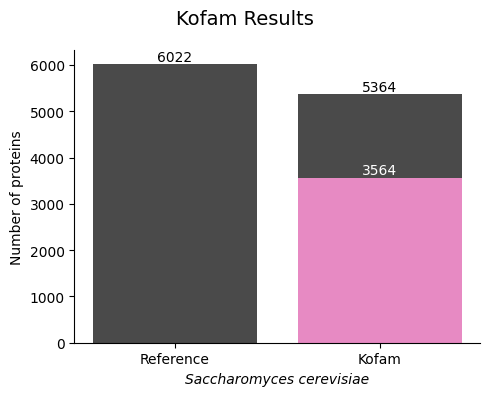

In [26]:
# Plot the results of kofam
# Colors
all_color = "#4a4a4a"
diff_color = "#e78ac3"
desc_color = "#66c2a5"
# variavel para cor branca
text = "#ffffff"

fig, ax = plt.subplots(figsize=(5, 4))
for loc, spine in ax.spines.items():
    if loc in ("bottom", "left"):
        spine.set_visible(True)
    else:
        spine.set_visible(False)

x_sac = ["Reference", "Kofam"]

# Plotar do maior para o menor ajuda a visualizar a sobreposição
ax.bar(x_sac[0], len(ref_sc[0]), color=all_color, label="All")
ax.bar(x_sac[1], len(sc_kofam_unique), color=all_color)
ax.bar(x_sac[1], len(sc_kofam_unique_star), color=diff_color, label="Significant")

ax.set_ylabel("Number of proteins")
# COlocar o número de proteínas em cada barra
ax.text(0, len(ref_sc[0]) + 5, str(len(ref_sc[0])), ha="center", va="bottom", fontsize=10)
ax.text(1, len(sc_kofam_unique) + 5, str(len(sc_kofam_unique)), ha="center", va="bottom", fontsize=10)
ax.text(1, len(sc_kofam_unique_star) + 5, str(len(sc_kofam_unique_star)), ha="center", va="bottom", fontsize=10, color=text)
ax.set_xlabel("Saccharomyces cerevisiae", fontstyle="italic")
fig.suptitle("Kofam Results", fontsize=14)

plt.tight_layout()
plt.show()

In [6]:
# Here we go trait pannzer2 results
sc_pannzer2_df = pd.read_csv(sc_pannzer2, sep="\t", dtype=str, comment="#", header=None, engine="python", quotechar='"')
# For select only unique ID, we need select for raw of the column 1 and select only have the term "DE"
sc_pannzer2_unique = sc_pannzer2_df[sc_pannzer2_df[1].str.contains("DE", na=False)]
sc_pannzer2_unique = sc_pannzer2_unique[~sc_pannzer2_unique[1].str.contains("original_DE", na=False)]
sc_pannzer2_unique_desc = sc_pannzer2_unique.drop(columns=[1, 2, 3, 4]).rename(columns={0: "Protein_ID", 5: "Pannzer2"})
sc_pannzer2_unique_desc

,Protein_ID,Pannzer2
2,rna-NM_001180043.1,Seripauperin-8
15,rna-NM_001178208.1,Transporter SEO1
31,rna-NM_001180041.1,Topoisomerase I damage affected protein 8
41,rna-NM_001178205.1,Flocculin protein FLO1L
49,rna-NM_001178204.1,Glutamate dehydrogenase
...,...,...
69627,rna-NM_001184296.1,Putative RNA polymerase II transcription factor
69636,rna-NM_001184297.1,Arsenical-resistance protein 2
69645,rna-NM_001184298.1,Arsenite efflux transporter ArsB
69661,rna-NM_001184301.1,Y' element ATP-dependent helicase YPR204W


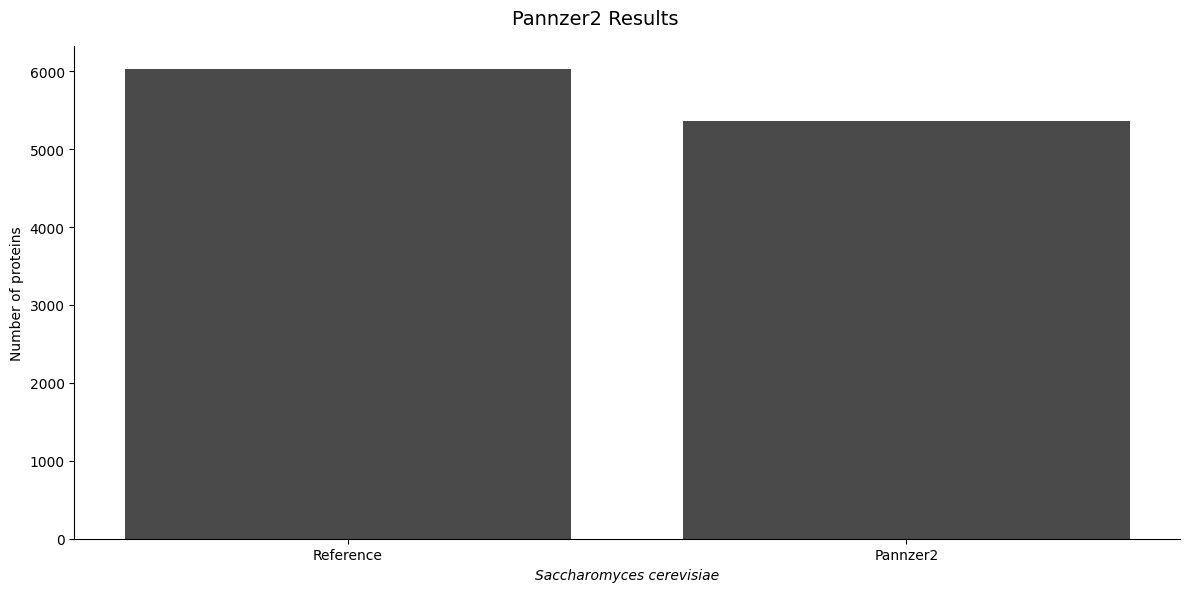

In [7]:
# Plot the results of pannzer2
fig, ax = plt.subplots(figsize=(12, 6))
for loc, spine in ax.spines.items():
    if loc in ("bottom", "left"):
        spine.set_visible(True)
    else:
        spine.set_visible(False)

x_sac = ["Reference", "Pannzer2"]

# Plotar do maior para o menor ajuda a visualizar a sobreposição
ax.bar(x_sac[0], len(ref_sc[0]), color=all_color, label="With description")
ax.bar(x_sac[1], len(sc_pannzer2_unique), color=all_color, label="Significant")

ax.set_ylabel("Number of proteins")
ax.set_xlabel("Saccharomyces cerevisiae", fontstyle="italic")
fig.suptitle("Pannzer2 Results", fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# Here we go trait eggnog
sc_eggnog_df = pd.read_csv(sc_eggnog, sep="\t", dtype=str, comment="#", header=None, engine="python", quotechar='"')

sc_eggnog_wi = sc_eggnog_df.copy()
mask = sc_eggnog_df[7].str.startswith(("to Saccharomyces cerevisiae", "Saccharomyces"), na=False)
sc_eggnog_wi.loc[mask, 7] = "Without information"
sc_eggnog_wi_total = sc_eggnog_wi[sc_eggnog_wi[7] == "Without information"]

sc_eggnog_desc = sc_eggnog_df.drop(columns=[1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]).rename(columns={0: "Protein_ID", 7: "EggNOG"})


,Protein_ID,EggNOG
0,rna-NM_001180357.1,Saccharomyces cerevisiae YDR049w
1,rna-NM_001180389.1,to Saccharomyces cerevisiae PDC2 (YDR081C)
2,rna-NM_001180455.3,to Saccharomyces cerevisiae KGD2 (YDR148C)
3,rna-NM_001180487.3,Saccharomyces cerevisiae YDR179wa
4,rna-NM_001184436.2,polyprotein is processed to make a nucleocapsi...
...,...,...
5492,rna-NM_001179665.1,Involved in nucleolar processing of pre-18S ri...
5493,rna-NM_001179634.1,to Saccharomyces cerevisiae NUP100 (YKL068W) a...
5494,rna-NM_001179601.3,to Saccharomyces cerevisiae YHL012W and UGP1 (...
5495,rna-NM_001179571.3,to Saccharomyces cerevisiae BYE1 (YKL005C)


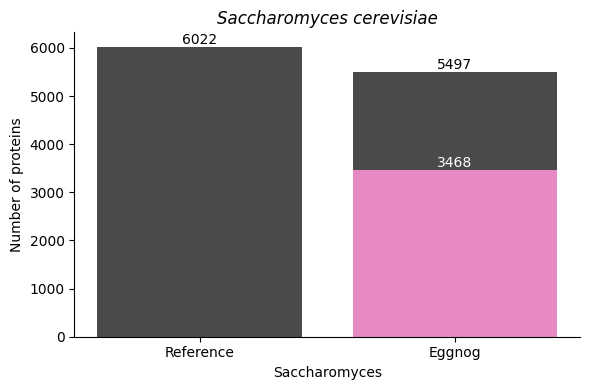

In [30]:
# Plot the results of eggnog
fig, ax = plt.subplots(figsize=(6, 4))
for loc, spine in ax.spines.items():
    if loc in ("bottom", "left"):
        spine.set_visible(True)
    else:
        spine.set_visible(False)

x_sac = ["Reference", "Eggnog"]

# Plotar do maior para o menor ajuda a visualizar a sobreposição
ax.bar(x_sac[0], len(ref_sc[0]), color=all_color)
ax.bar(x_sac[1], len(sc_eggnog_df[0]), color=all_color)
ax.bar(x_sac[1], len(sc_eggnog_wi_total[0]), color=diff_color, label="Without information")
ax.text(0, len(ref_sc[0]) + 5, str(len(ref_sc[0])), ha="center", va="bottom", fontsize=10)
ax.text(1, len(sc_eggnog_df[0]) + 5, str(len(sc_eggnog_df[0])), ha="center", va="bottom", fontsize=10)
ax.text(1, len(sc_eggnog_wi_total[0]) + 5, str(len(sc_eggnog_wi_total[0])), ha="center", va="bottom", fontsize=10, color=text)
ax.set_title("Saccharomyces cerevisiae", fontstyle="italic")
ax.set_ylabel("Number of proteins")
ax.set_xlabel("Saccharomyces")

plt.tight_layout()
plt.show()

In [10]:
# Here we go trait interproscan results
sc_interproscan_df = pd.read_csv(sc_interproscan, sep="\t", dtype=str, comment="#", header=None, engine="python", quoting=csv.QUOTE_NONE)

sc_interproscan_filtered = sc_interproscan_df.loc[sc_interproscan_df[3].str.contains("PANTHER|NCBIfam|SFLD|Hamap|PIRSF", na=False)]
sc_interproscan_filtered_final = sc_interproscan_filtered.loc[sc_interproscan_filtered.groupby(0)[8].idxmin()]
sc_interproscan_desc = sc_interproscan_filtered_final.drop(columns=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14]).rename(columns={0: "Protein_ID", 12: "InterProScan"})
sc_interproscan_desc

,Protein_ID,InterProScan
16506,rna-NM_001178148.1,Transcription factor Tfc3-like
39163,rna-NM_001178149.1,Vacuolar protein sorting-associated protein Vp...
53630,rna-NM_001178150.1,"Translation elongation factor EF1B, beta/delta..."
23644,rna-NM_001178151.1,Heat shock protein 70 family
21793,rna-NM_001178152.1,Transmembrane emp24 domain-containing protein
...,...,...
11097,rna-NM_001281536.2,Retrotransposon Ty1/copia-like
35310,rna-NM_001305015.2,Retrotransposon Ty1/copia-like
10678,rna-NM_001431138.1,Mitophagy receptor Atg43
49089,rna-Q0080,"ATP synthase protein 8, fungal type"


/home/marymardegan/miniconda3/envs/upset_env/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/marymardegan/miniconda3/envs/upset_env/lib/python3.10/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on

Text(0.5, 0.98, '$\\it{Saccharomyces}$ $\\it{cerevisiae}$ IDs similarity between tools')

<Figure size 1000x2000 with 0 Axes>

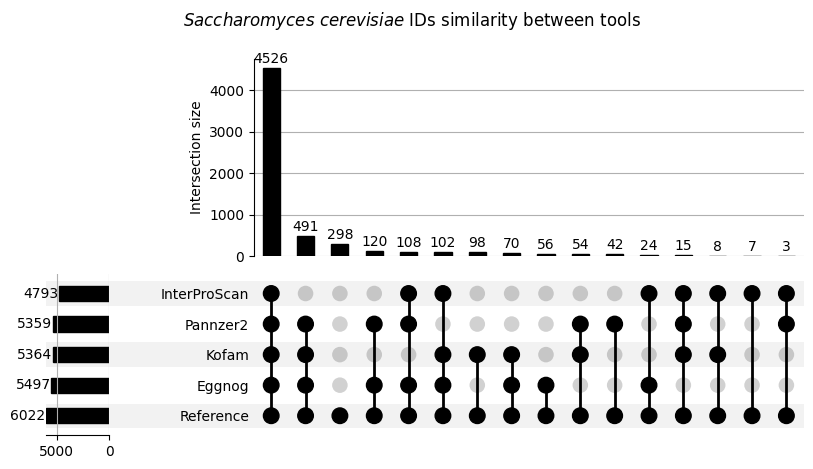

In [18]:
# aqui a gente vai pegar todas as df tratadas para unir 
df_ref = ref_sc[0].copy().to_frame(name="Protein_ID")
df_ref["Source"] = "Reference"
df_kofam = sc_kofam_unique[1].copy().to_frame(name="Protein_ID")
df_kofam["Source"] = "Kofam"
df_pannzer2 = sc_pannzer2_unique[0].copy().to_frame(name="Protein_ID")
df_pannzer2["Source"] = "Pannzer2"
df_eggnog = sc_eggnog_df[0].copy().to_frame(name="Protein_ID")
df_eggnog["Source"] = "Eggnog"
df_interpro = sc_interproscan_filtered_final[0].copy().to_frame(name="Protein_ID")
df_interpro["Source"] = "InterProScan"

# Concatenar os dataframes
sc_all = pd.concat([df_ref, df_kofam, df_pannzer2, df_eggnog, df_interpro], ignore_index=True)
sc_all

# UpSetPlot works very well with a presence/absence matrix
sc_upset = pd.crosstab(sc_all["Protein_ID"], sc_all["Source"]).astype(bool)
sc_upset

upset_data = from_indicators(sc_upset.columns, sc_upset)
upset = UpSet(upset_data, subset_size="count", show_counts="%d", sort_by="cardinality", sort_categories_by="cardinality")
fig = plt.figure(figsize=(10, 20))

upset.plot()
plt.suptitle(r"$\it{Saccharomyces}$ $\it{cerevisiae}$ IDs similarity between tools") 

In [12]:
# Now we will concat all value of ID and description
df_informative = ref_sc.copy()
ref_desc = df_informative.iloc[1:].rename(columns={0: "Protein_ID", 1: "Reference"})

In [13]:
merge_all = pd.merge(ref_desc[["Protein_ID", "Reference"]], sc_kofam_unique_star_desc[["Protein_ID", "Kofam"]], how= "right", on="Protein_ID")
merge_all = pd.merge(merge_all, sc_pannzer2_unique_desc[["Protein_ID", "Pannzer2"]], how= "right", on="Protein_ID")
merge_all = pd.merge(merge_all, sc_eggnog_desc[["Protein_ID", "EggNOG"]], how= "right", on="Protein_ID")
merge_all = pd.merge(merge_all, sc_interproscan_desc[["Protein_ID", "InterProScan"]], how= "right", on="Protein_ID")

merge_all

,Protein_ID,Reference,Kofam,Pannzer2,EggNOG,InterProScan
0,rna-NM_001178148.1,transcription factor TFIIIC subunit TFC3,transcription factor C subunit 3,Transcription factor tau 138 kDa subunit,to Saccharomyces cerevisiae TFC3 (YAL001C),Transcription factor Tfc3-like
1,rna-NM_001178149.1,CORVET complex membrane-binding subunit VPS8,vacuolar protein sorting-associated protein 8,Vacuolar protein sorting-associated protein VPS8,to Saccharomyces cerevisiae VPS8 (YAL002W),Vacuolar protein sorting-associated protein Vp...
2,rna-NM_001178150.1,translation elongation factor 1 subunit beta,elongation factor 1-beta,Similar to Saccharomyces cerevisiae YAL003W EF...,Belongs to the EF-1-beta EF-1-delta family,"Translation elongation factor EF1B, beta/delta..."
3,rna-NM_001178151.1,Hsp70 family ATPase SSA1,heat shock 70kDa protein 1/6/8,Heat shock protein SSA2,Belongs to the heat shock protein 70 family,Heat shock protein 70 family
4,rna-NM_001178152.1,NaN,NaN,ERP2p Member of the p24 family involved in ER ...,to Saccharomyces cerevisiae ERP4 (YOR016C) and...,Transmembrane emp24 domain-containing protein
...,...,...,...,...,...,...
4788,rna-NM_001281536.2,NaN,NaN,Truncated transposon Ty1-A Gag-Pol polyprotein,polyprotein is processed to make a nucleocapsi...,Retrotransposon Ty1/copia-like
4789,rna-NM_001305015.2,NaN,NaN,Transposon Ty4-H Gag-Pol polyprotein,Ty like retrotransposon,Retrotransposon Ty1/copia-like
4790,rna-NM_001431138.1,NaN,NaN,NaN,to Saccharomyces cerevisiae ADL119W (Scer_YGOB...,Mitophagy receptor Atg43
4791,rna-Q0080,NaN,NaN,NaN,ATP synthesis coupled proton transport,"ATP synthase protein 8, fungal type"


In [14]:
def classify_description(product_text):
    if pd.isna(product_text):
        return 'Missing'
    
    text = str(product_text).lower().strip()
    
    vague_terms = [
        'hypothetical',
        'uncharacterized',
        'unknown',
        'putative',
        'duf',
        'domain of unknown function'
    ]
    
    if text == '':
        return 'Missing'
    
    if any(term in text for term in vague_terms):
        return 'Uninformative'
    
    return 'Informative'

merged_df = merge_all.copy()

tools = ['Reference', 'Kofam', 'Pannzer2', 'EggNOG', 'InterProScan']

for tool in tools:
    status_col = f'status_{tool}'
    merged_df[status_col] = merged_df[tool].apply(classify_description)

comparison_results = []
tools_to_evaluate = ['Kofam', 'EggNOG', 'Pannzer2', 'InterProScan']

for tool in tools_to_evaluate:
    tool_status = merged_df[f'status_{tool}']
    ref_status = merged_df['status_Reference']
    
    for i in range(len(merged_df)):
        t_val = tool_status.iloc[i]
        r_val = ref_status.iloc[i]
        
        if t_val == 'Missing' and r_val == 'Missing':
            category = 'Both Uninformative'
        elif t_val == 'Missing' and r_val != 'Missing':
            category = 'Under-Annotation'
        elif t_val != 'Missing' and r_val == 'Missing':
            category = 'Over-Annotation'
        elif t_val == 'Informative' and r_val == 'Informative':
            category = 'Both Informative'
        elif t_val == 'Uninformative' and r_val == 'Uninformative':
            category = 'Both Uninformative'
        elif t_val == 'Informative' and r_val == 'Uninformative':
            category = 'Over-Annotation'
        elif t_val == 'Uninformative' and r_val == 'Informative':
            category = 'Under-Annotation'
        else:
            category = 'Other'
        
        comparison_results.append({
            'Tool': tool,
            'Category': category
        })

df_plot = pd.DataFrame(comparison_results)

summary_table = df_plot.groupby(['Tool', 'Category']).size().unstack(fill_value=0)

col_order = [
    'Both Informative',
    'Both Uninformative',
    'Over-Annotation',
    'Under-Annotation',
]

summary_table = summary_table.reindex(columns=col_order, fill_value=0)

display(summary_table)

Category,Both Informative,Both Uninformative,Over-Annotation,Under-Annotation
Tool,,,,
EggNOG,3139,34,1619,1
InterProScan,3136,0,1653,4
Kofam,3130,1503,150,10
Pannzer2,3112,170,1483,28


In [15]:
# def is_informative(product_text):
#     if pd.isna(product_text):
#         return False
       
#     text = str(product_text).lower().strip()
   
#     vague_terms = [
#         'hypothetical',
#         'uncharacterized',
#         'unknown',
#         'putative',
#         'duf',
#         'domain of unknown function'
#     ]
   
#     if any(term in text for term in vague_terms) or text == '':
#         return False
   
#     return True

# merged_df = merge_all.copy()

# tools = ['Reference', 'Kofam', 'Pannzer2', 'EggNOG', 'InterProScan']

# for tool in tools:
#     info_col = f'is_info_{tool}'
#     merged_df[info_col] = merged_df[tool].apply(is_informative)

# comparison_results = []
# tools_to_evaluate = ['Kofam', 'EggNOG', 'Pannzer2', 'InterProScan']

# for tool in tools_to_evaluate:
#     tool_info = merged_df[f'is_info_{tool}']
#     ref_info = merged_df['is_info_Reference']
   
#     for i in range(len(merged_df)):
#         t_val = tool_info.iloc[i]
#         r_val = ref_info.iloc[i]
       
#         if t_val == True and r_val == True:
#             category = 'Both Informative'
#         elif t_val == False and r_val == False:
#             category = 'Both Hypothetical'
#         elif t_val == True and r_val == False:
#             category = 'Over-Annotation'
#         elif t_val == False and r_val == True:
#             category = 'Under-Annotation'
           
#         comparison_results.append({
#             'Tool': tool,
#             'Category': category
#         })

# df_plot = pd.DataFrame(comparison_results)
# summary_table = df_plot.groupby(['Tool', 'Category']).size().unstack(fill_value=0)

# col_order = ['Both Informative', 'Both Hypothetical', 'Over-Annotation', 'Under-Annotation']
# summary_table = summary_table.reindex(columns=col_order, fill_value=0)

# print("--- Functional Summary: Tool vs Reference ---")
# display(summary_table)

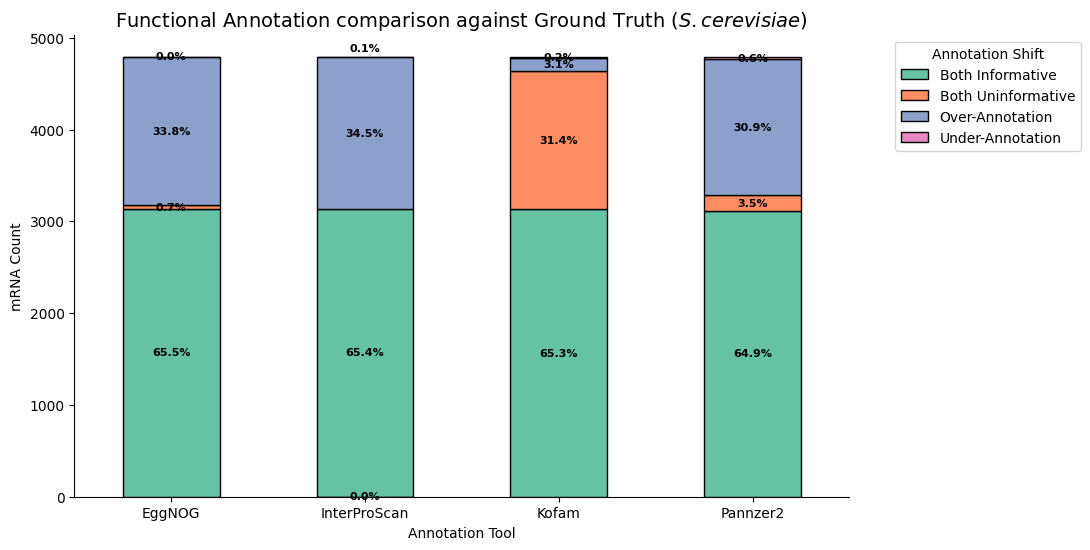

In [16]:
custom_color_map = {
    'Both Informative': '#66c2a5',  
    'Both Uninformative': '#fc8d62',
    'Over-Annotation': '#8da0cb',  
    'Under-Annotation': '#e78ac3'    
}
summary_table.plot(kind='bar', stacked=True, figsize=(10, 6), color=[custom_color_map[cat] for cat in summary_table.columns], edgecolor='black')
plt.title("Functional Annotation comparison against Ground Truth ($\it{S. cerevisiae}$)", fontsize=14)
for loc, spine in plt.gca().spines.items():
    if loc in ("bottom", "left"):
        spine.set_visible(True)
    else:
        spine.set_visible(False)
plt.ylabel("mRNA Count")
plt.xlabel("Annotation Tool")
plt.xticks(rotation=0)
plt.legend(title="Annotation Shift",
           bbox_to_anchor=(1.05, 1),
           loc='upper left')
total = summary_table.sum(axis=1).iloc[0]
ax = plt.gca()


for idx, container in enumerate(ax.containers):
    labels = [f'{v/total*100:.1f}%' for v in container.datavalues]
    text_objs = ax.bar_label(container, labels=labels,
                             label_type='center',
                             fontsize=8,
                             fontweight='bold')
    if idx == 3:
        text_objs[1].set_y(text_objs[1].get_position()[1] + 6)



In [17]:
def is_informative(product_text):
    if pd.isna(product_text):
        return False
       
    text = str(product_text).lower().strip()
   
    vague_terms = ['hypothetical', 'uncharacterized', 'unknown', 'putative', 'duf', 'DUF', 'domain of unknown function']
   
    if any(term in text for term in vague_terms) or text == '':
        return False
   
    return True

merged_df = merge_all.fillna("Don't have description")

tools = ['Reference', 'Kofam', 'Pannzer2', 'EggNOG', 'InterProScan']
for tool in tools:
    col_name = f'{tool}_description'
    info_col = f'is_info_{tool}'
    merged_df[info_col] = merged_df[col_name].apply(is_informative)


comparison_results = []
tools_to_evaluate = ['Kofam', 'EggNOG', 'Pannzer2', 'InterProScan']


for tool in tools_to_evaluate:
    tool_info = merged_df[f'is_info_{tool}']
    ref_info = merged_df['is_info_Reference']
   
    for i in range(len(merged_df)):
        t_val = tool_info.iloc[i]
        r_val = ref_info.iloc[i]
       
        if t_val == True and r_val == True:
            category = 'Both Informative'
        elif t_val == False and r_val == False:
            category = 'Both Hypothetical'
        elif t_val == True and r_val == False:
            category = 'Over-Annotation'
        elif t_val == False and r_val == True:
            category = 'Under-Annotation'
           
        comparison_results.append({
            'Tool': tool,
            'Category': category
        })


df_plot = pd.DataFrame(comparison_results)
summary_table = df_plot.groupby(['Tool', 'Category']).size().unstack(fill_value=0)


col_order = ['Both Informative', 'Both Hypothetical', 'Over-Annotation', 'Under-Annotation']
summary_table = summary_table[col_order]


print("--- Resumo Funcional: Ferramenta vs Referência ---")
display(summary_table)

KeyError: 'Reference_description'